Loaded delta-100-0.txt: angle=0.0°, Fx=3.770e+01, Fy=0.000e+00, components=x, n_points=30
Added experimental noise: 2% of peak |data|=11.52 -> sigma_noise_added=0.2303, realized sigma_noise=0.1789 
Automatic sigma prior scale: max fitted displacement=11.5155, 10% max displacement=1.15155, beta=1/(10% max displacement)=0.868397
sigma_noise prior: Exp(beta=0.8684)
Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\data_vs_noise.pdf


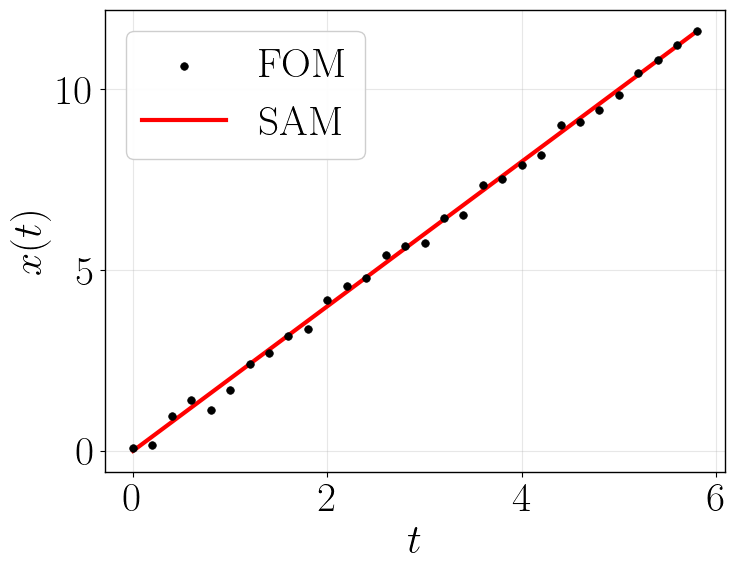

Saved figure: c:\Users\paraj\Documents\particle_inference_test\examples\plots\prior.pdf


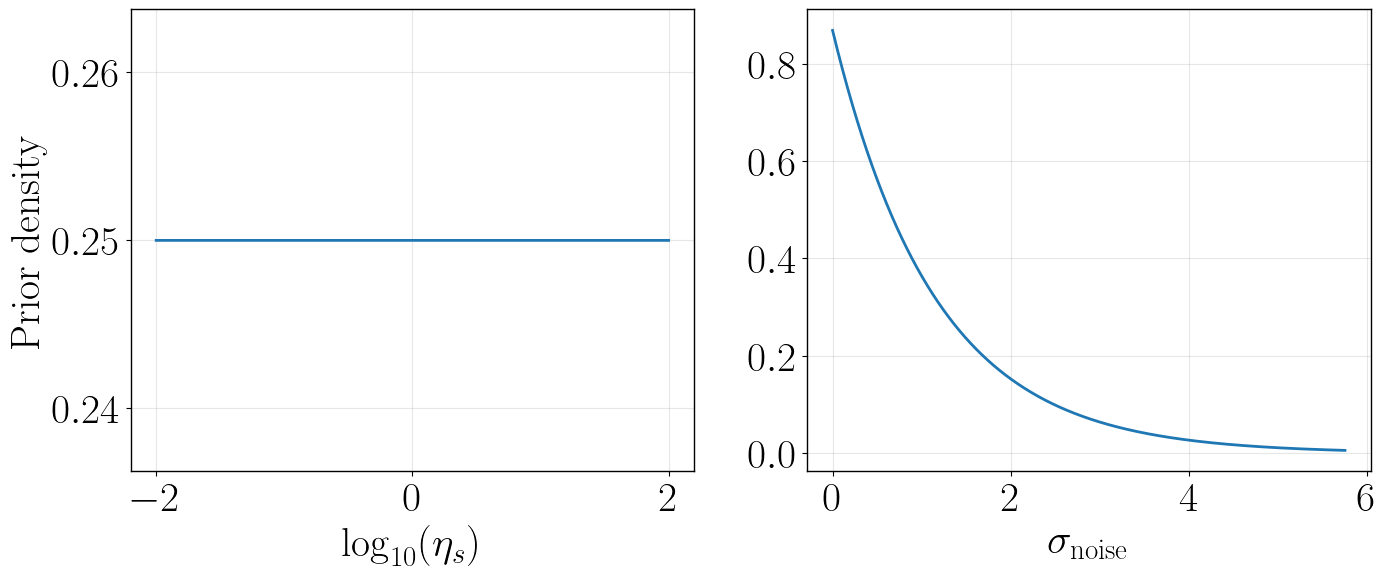


Preparing MCMC: ndim=2, walkers=4, steps=10000, init=kmeans, warmup=True

Initial walkers (physical):
  00: [0.11749947 0.49741914]
  01: [11.08667363  0.78760333]
  02: [3.9040478  4.29991786]
  03: [0.10838325 2.30179785]

Warm-up: 1000 steps x 4 walkers


Warm-up:   0%|          | 0/1000 [00:00<?, ?it/s]


Walkers after warm-up (physical):
  00: [1.00918388 0.22019199]
  01: [0.99315191 0.11491704]
  02: [0.96655975 0.23965971]
  03: [1.00476133 0.1888489 ]


MCMC:   0%|          | 0/10000 [00:00<?, ?it/s]

In [ ]:
import sys
import os

CURRENT_DIR = os.getcwd()
FAXEN_ROOT = os.path.abspath(os.path.join(CURRENT_DIR, '..'))
sys.path.append(FAXEN_ROOT)
from packages.main import InferenceProcedure
import numpy as np

model = InferenceProcedure(
    force=12*np.pi,
    material_model="newtonian", # "newtonian", "viscoelastic"
    boundary_model="unbounded", # "unbounded", "bounded"
    theta=0, 
    a=1.0,
    sigma_noise_percent= 2.0,
    sigma_bias=None,
    nsteps=10000,
    thin_factor=1)

model.load_data("newtonian/unbounded/delta-100-0.txt")
model.plot_data(theta_true=[1])
model.plot_prior()
model.run_mcmc(init_method= "kmeans")
model.plot_results()